In [1]:
pip install statsmodels pysal

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  Getting requirements to build wheel did not run successfully.
  exit code: 1
  
  [1 lines of output]
  CRITICAL:root:A GDAL API version must be specified. Provide a path to gdal-config using a GDAL_CONFIG environment variable or use a GDAL_VERSION environment variable.
  [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Failed to build 'fiona' when getting requirements to build wheel


In [2]:
pip install statsmodels libpysal esda spreg

  Using cached statsmodels-0.14.6-cp314-cp314-win_amd64.whl.metadata (9.8 kB)
  Using cached spreg-1.9.0-py3-none-any.whl.metadata (1.7 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ------ --------------------------------- 1.6/9.6 MB 12.3 MB/s eta 0:00:01
   ---------------- ----------------------- 3.9/9.6 MB 12.0 MB/s eta 0:00:01
   --------------------------- ------------ 6.6/9.6 MB 11.9 MB/s eta 0:00:01
   --------------------------- ------------ 6.6/9.6 MB 11.9 MB/s eta 0:00:01
   --------------------------------- ------ 8.1/9.6 MB 8.3 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 8.4 MB/s  0:00:01

   ------------- -------------------------- 1/3 [statsmodels]
   ------------- -------------------------- 1/3 [statsmodels]
   ------------- -------------------------- 1/3 [statsmodels]
   ------------- -------------------------- 1/3 [statsmodels]
   ------------- --


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import statsmodels.api as sm
from libpysal.weights import Queen
from esda.moran import Moran
from spreg import ML_Lag

print("Todo OK")

Todo OK


In [8]:
import pandas as pd
import geopandas as gpd
from shapely import wkt
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

from libpysal.weights import Queen
from esda.moran import Moran
from spreg import ML_Lag


def run_sar_city(path, city_name):
    
    print(f"\n==================== {city_name} ====================")
    
    # 1. Cargar
    df = pd.read_csv(path)
    
    # 2. Geometría
    df["geometry"] = df["GEOM_WKT"].apply(wkt.loads)
    gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")
    
    # 3. Variables
    y_var = "IND_MULTIDIM"
    
    X_vars = [
        "estrato_promedio",
        "personas_por_dormitorio",
        "pct_alfabeta",
        "pct_asistencia",
        "pct_trabaja",
        "pct_con_acueducto",
        "pct_con_alcantarillado",
        "pct_con_gas",
        "pct_con_internet"
    ]
    
    gdf_model = gdf[[y_var] + X_vars + ["geometry"]].dropna().reset_index(drop=True)
    
    print("Filas iniciales:", gdf_model.shape[0])
    
    # 4. Correlación
    print("\n--- Correlación ---")
    corr = gdf_model[X_vars].corr()
    print(corr.round(2))
    
    plt.figure(figsize=(6,5))
    sns.heatmap(corr, cmap="coolwarm")
    plt.title(f"{city_name} - Correlación")
    plt.show()
    
    # 5. Matriz espacial inicial
    w = Queen.from_dataframe(gdf_model)
    islands = w.islands
    
    print("\nIslas detectadas:", len(islands))
    
    # 6. Eliminar islas y reconstruir matriz
    if len(islands) > 0:
        gdf_model = gdf_model.drop(index=islands).reset_index(drop=True)
        w = Queen.from_dataframe(gdf_model)
    
    w.transform = "r"
    
    print("Observaciones finales:", gdf_model.shape[0])
    
    # 7. OLS
    y = gdf_model[y_var].values
    X = gdf_model[X_vars].values
    X = sm.add_constant(X)
    
    ols = sm.OLS(y, X).fit()
    
    print("\n--- OLS ---")
    print("R2:", round(ols.rsquared, 3))
    print("AIC:", round(ols.aic, 2))
    
    # 8. Moran sobre residuos
    moran = Moran(ols.resid, w)
    
    print("\n--- Moran ---")
    print("I:", round(moran.I, 4))
    print("p-value:", round(moran.p_sim, 4))
    
    # 9. SAR
    sar = ML_Lag(
        y,
        X,
        w=w,
        name_y=y_var,
        name_x=["const"] + X_vars
    )
    
    print("\n--- SAR ---")
    print("Rho:", round(float(sar.rho), 4))
    print("AIC:", round(float(sar.aic), 2))
    
    # 10. Coeficientes
    coef_sar = pd.Series(
        sar.betas.flatten(),
        index=["const"] + X_vars + ["rho"]
    )
    
    print("\nCoeficientes SAR:")
    print(coef_sar.round(4))
    
    # 11. Comparación
    print("\n--- Comparación ---")
    print("AIC OLS:", round(ols.aic, 2))
    print("AIC SAR:", round(float(sar.aic), 2))
    
    return {
        "gdf_model": gdf_model,
        "ols": ols,
        "sar": sar,
        "moran": moran,
        "coef_sar": coef_sar
    }


==================== Armenia ====================
Filas iniciales: 3172

--- Correlación ---
                         estrato_promedio  personas_por_dormitorio  \
estrato_promedio                     1.00                    -0.53   
personas_por_dormitorio             -0.53                     1.00   
pct_alfabeta                         0.24                    -0.18   
pct_asistencia                      -0.07                     0.11   
pct_trabaja                         -0.01                     0.03   
pct_con_acueducto                    0.14                    -0.23   
pct_con_alcantarillado              -0.02                    -0.11   
pct_con_gas                          0.09                    -0.27   
pct_con_internet                     0.67                    -0.57   

                         pct_alfabeta  pct_asistencia  pct_trabaja  \
estrato_promedio                 0.24           -0.07        -0.01   
personas_por_dormitorio         -0.18            0.11         0.0

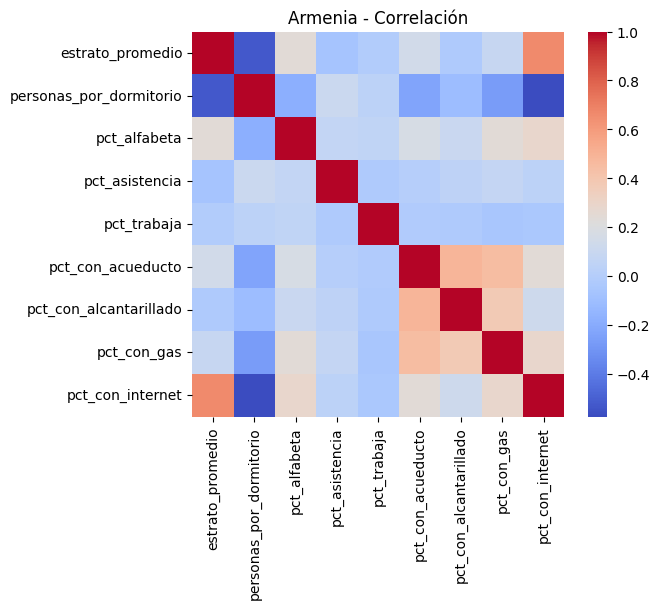

C:\Users\Usuario\AppData\Local\Temp\ipykernel_23096\2281350537.py:54: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf_model)
C:\Users\Usuario\Documents\PROYECTO DE GRADO\venv\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 2629 disconnected components.
 There are 2511 islands with ids: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 20, 21, 22, 26, 27, 28, 29, 30, 31, 32, 33, 39, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 65, 66, 67, 68, 70, 71, 72, 73, 78, 83, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145,


Islas detectadas: 2511


C:\Users\Usuario\Documents\PROYECTO DE GRADO\venv\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 118 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


Observaciones finales: 661

--- OLS ---
R2: 0.928
AIC: -3343.69

--- Moran ---
I: 0.1323
p-value: 0.001
ML_Lag

--- SAR ---
Rho: 0.0311
AIC: -3349.09

Coeficientes SAR:
const                      0.3294
estrato_promedio          -0.0130
personas_por_dormitorio    0.0324
pct_alfabeta               0.0004
pct_asistencia            -0.0000
pct_trabaja               -0.0001
pct_con_acueducto         -0.0010
pct_con_alcantarillado    -0.0005
pct_con_gas               -0.0008
pct_con_internet          -0.0008
rho                        0.0311
dtype: float64

--- Comparación ---
AIC OLS: -3343.69
AIC SAR: -3349.09


In [9]:
armenia_results = run_sar_city(
    "ETAPA 4 - CLUSTERING/outputs/armenia_clusters_final_extra.csv",
    "Armenia"
)


==================== Pereira ====================
Filas iniciales: 3952

--- Correlación ---
                         estrato_promedio  personas_por_dormitorio  \
estrato_promedio                     1.00                    -0.59   
personas_por_dormitorio             -0.59                     1.00   
pct_alfabeta                         0.24                    -0.21   
pct_asistencia                      -0.11                     0.11   
pct_trabaja                         -0.01                     0.00   
pct_con_acueducto                    0.11                    -0.18   
pct_con_alcantarillado               0.11                    -0.19   
pct_con_gas                          0.07                    -0.22   
pct_con_internet                     0.62                    -0.57   

                         pct_alfabeta  pct_asistencia  pct_trabaja  \
estrato_promedio                 0.24           -0.11        -0.01   
personas_por_dormitorio         -0.21            0.11         0.0

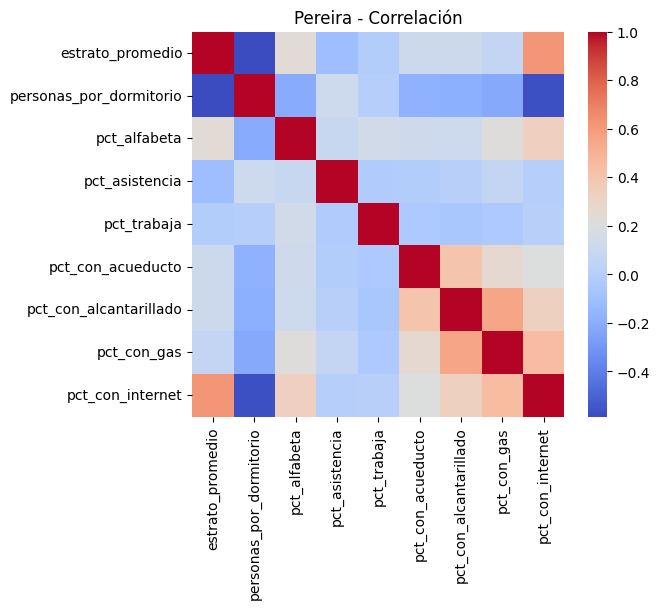

C:\Users\Usuario\AppData\Local\Temp\ipykernel_23096\2281350537.py:54: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf_model)
C:\Users\Usuario\Documents\PROYECTO DE GRADO\venv\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 3685 disconnected components.
 There are 3576 islands with ids: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 27, 28, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124


Islas detectadas: 3576
Observaciones finales: 376

--- OLS ---
R2: 0.915
AIC: -1814.58

--- Moran ---
I: 0.1813
p-value: 0.002
ML_Lag

--- SAR ---
Rho: 0.033
AIC: -1816.65

Coeficientes SAR:
const                      0.3848
estrato_promedio          -0.0101
personas_por_dormitorio    0.0340
pct_alfabeta               0.0000
pct_asistencia            -0.0001
pct_trabaja               -0.0004
pct_con_acueducto         -0.0013
pct_con_alcantarillado    -0.0004
pct_con_gas               -0.0007
pct_con_internet          -0.0007
rho                        0.0330
dtype: float64

--- Comparación ---
AIC OLS: -1814.58
AIC SAR: -1816.65


In [10]:
pereira_results = run_sar_city(
    "ETAPA 4 - CLUSTERING/outputs/pereira_clusters_final_extra.csv",
    "Pereira"
)


==================== Cali ====================
Filas iniciales: 13464

--- Correlación ---
                         estrato_promedio  personas_por_dormitorio  \
estrato_promedio                     1.00                    -0.62   
personas_por_dormitorio             -0.62                     1.00   
pct_alfabeta                         0.17                    -0.09   
pct_asistencia                      -0.12                     0.20   
pct_trabaja                          0.13                    -0.09   
pct_con_acueducto                    0.10                    -0.15   
pct_con_alcantarillado               0.14                    -0.16   
pct_con_gas                          0.22                    -0.30   
pct_con_internet                     0.65                    -0.60   

                         pct_alfabeta  pct_asistencia  pct_trabaja  \
estrato_promedio                 0.17           -0.12         0.13   
personas_por_dormitorio         -0.09            0.20        -0.09 

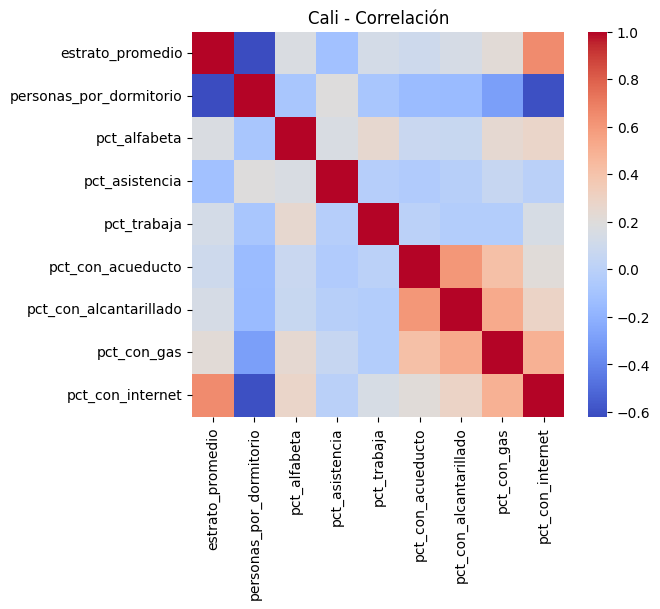

C:\Users\Usuario\AppData\Local\Temp\ipykernel_23096\2281350537.py:54: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf_model)
C:\Users\Usuario\Documents\PROYECTO DE GRADO\venv\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 13209 disconnected components.
 There are 13075 islands with ids: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 99, 100, 106, 107, 109, 110, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133


Islas detectadas: 13075
Observaciones finales: 389

--- OLS ---
R2: 0.929
AIC: -1936.06

--- Moran ---
I: 0.1422
p-value: 0.009
ML_Lag

--- SAR ---
Rho: 0.0456
AIC: -1938.8

Coeficientes SAR:
const                      0.2057
estrato_promedio          -0.0089
personas_por_dormitorio    0.0228
pct_alfabeta               0.0012
pct_asistencia            -0.0001
pct_trabaja               -0.0002
pct_con_acueducto         -0.0007
pct_con_alcantarillado    -0.0004
pct_con_gas               -0.0005
pct_con_internet          -0.0009
rho                        0.0456
dtype: float64

--- Comparación ---
AIC OLS: -1936.06
AIC SAR: -1938.8


In [11]:
cali_results = run_sar_city(
    "ETAPA 4 - CLUSTERING/outputs/cali_clusters_final_extra.csv",
    "Cali"
)

In [14]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def export_sar_outputs(results, city_name, output_dir="ETAPA 7 - SAR/outputs"):
    os.makedirs(output_dir, exist_ok=True)
    
    city_slug = city_name.lower().replace(" ", "_")
    
    gdf_model = results["gdf_model"].copy()
    ols = results["ols"]
    sar = results["sar"]
    moran = results["moran"]
    coef_sar = results["coef_sar"]
    
    # ----------------------------
    # 1. TXT resumen completo
    # ----------------------------
    txt_path = os.path.join(output_dir, f"{city_slug}_sar_resumen.txt")
    
    with open(txt_path, "w", encoding="utf-8") as f:
        f.write(f"RESULTADOS SAR - {city_name}\n")
        f.write("="*60 + "\n\n")
        
        f.write("OLS SUMMARY\n")
        f.write("-"*60 + "\n")
        f.write(str(ols.summary()))
        f.write("\n\n")
        
        f.write("MORAN SOBRE RESIDUOS OLS\n")
        f.write("-"*60 + "\n")
        f.write(f"Moran I: {moran.I}\n")
        f.write(f"p-value: {moran.p_sim}\n\n")
        
        f.write("SAR SUMMARY\n")
        f.write("-"*60 + "\n")
        f.write(str(sar.summary))
        f.write("\n\n")
        
        f.write("COEFICIENTES SAR\n")
        f.write("-"*60 + "\n")
        f.write(coef_sar.to_string())
        f.write("\n")
    
    # ----------------------------
    # 2. CSV coeficientes SAR
    # ----------------------------
    coef_path = os.path.join(output_dir, f"{city_slug}_coeficientes_sar.csv")
    coef_sar.to_csv(coef_path, header=["coeficiente"])
    
    # ----------------------------
    # 3. CSV métricas resumen
    # ----------------------------
    resumen = pd.DataFrame({
        "Ciudad": [city_name],
        "N_observaciones": [gdf_model.shape[0]],
        "R2_OLS": [ols.rsquared],
        "AIC_OLS": [ols.aic],
        "Moran_I": [moran.I],
        "Moran_pvalue": [moran.p_sim],
        "Rho_SAR": [float(sar.rho)],
        "AIC_SAR": [float(sar.aic)]
    })
    
    resumen_path = os.path.join(output_dir, f"{city_slug}_metricas_resumen.csv")
    resumen.to_csv(resumen_path, index=False)
    
    # ----------------------------
    # 4. CSV residuos OLS
    # ----------------------------
    gdf_model["resid_ols"] = ols.resid
    gdf_model["y_real"] = ols.model.endog
    gdf_model["y_pred_ols"] = ols.fittedvalues
    
    resid_path = os.path.join(output_dir, f"{city_slug}_residuos_ols.csv")
    gdf_model.drop(columns="geometry").to_csv(resid_path, index=False)
    
    # ----------------------------
    # 5. Gráfico coeficientes SAR
    # ----------------------------
    coef_plot = coef_sar.drop("const", errors="ignore").drop("rho", errors="ignore")
    
    plt.figure(figsize=(8,5))
    coef_plot.sort_values().plot(kind="barh")
    plt.title(f"{city_name} - Coeficientes SAR")
    plt.xlabel("Coeficiente")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"{city_slug}_coeficientes_sar.png"), dpi=300)
    plt.show()
    
    # ----------------------------
    # 6. Gráfico comparación OLS vs real
    # ----------------------------
    plt.figure(figsize=(6,6))
    plt.scatter(gdf_model["y_real"], gdf_model["y_pred_ols"], alpha=0.6)
    plt.xlabel("IND_MULTIDIM real")
    plt.ylabel("Predicción OLS")
    plt.title(f"{city_name} - Real vs Predicho OLS")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"{city_slug}_real_vs_pred_ols.png"), dpi=300)
    plt.show()
    
    # ----------------------------
    # 7. Histograma residuos OLS
    # ----------------------------
    plt.figure(figsize=(6,4))
    plt.hist(gdf_model["resid_ols"], bins=30)
    plt.title(f"{city_name} - Distribución residuos OLS")
    plt.xlabel("Residuo")
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"{city_slug}_hist_residuos_ols.png"), dpi=300)
    plt.show()
    
    # ----------------------------
    # 8. Mapa simple IND_MULTIDIM
    # ----------------------------
    plt.figure(figsize=(8,8))
    gdf_model.plot(column="IND_MULTIDIM", legend=True)
    plt.title(f"{city_name} - IND_MULTIDIM")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"{city_slug}_mapa_ind_multidim.png"), dpi=300)
    plt.show()
    
    # ----------------------------
    # 9. Mapa residuos OLS
    # ----------------------------
    plt.figure(figsize=(8,8))
    gdf_model.plot(column="resid_ols", legend=True)
    plt.title(f"{city_name} - Residuos OLS")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"{city_slug}_mapa_residuos_ols.png"), dpi=300)
    plt.show()
    
    print(f"\nArchivos exportados para {city_name} en: {output_dir}")

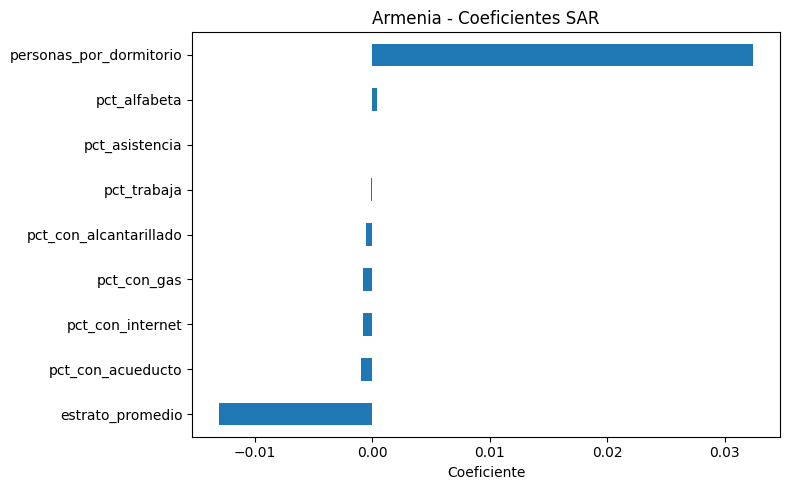

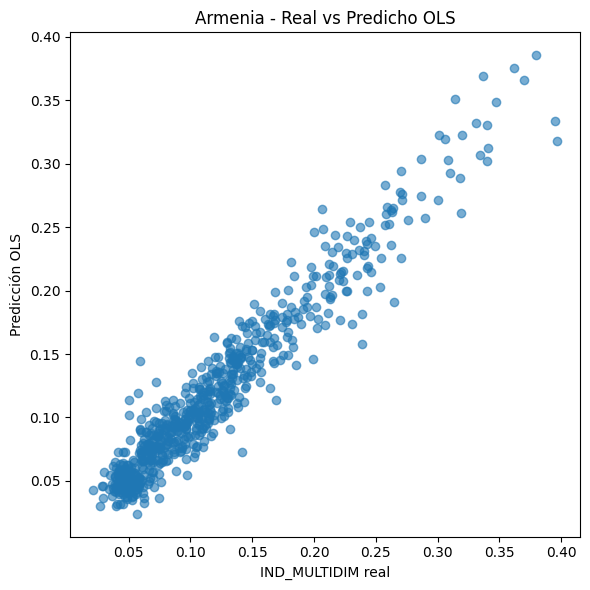

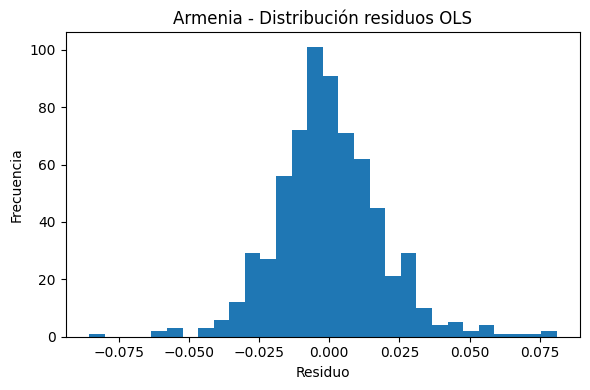

<Figure size 800x800 with 0 Axes>

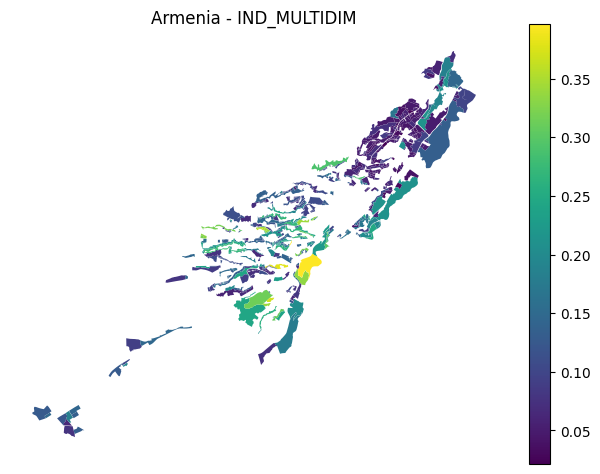

<Figure size 800x800 with 0 Axes>

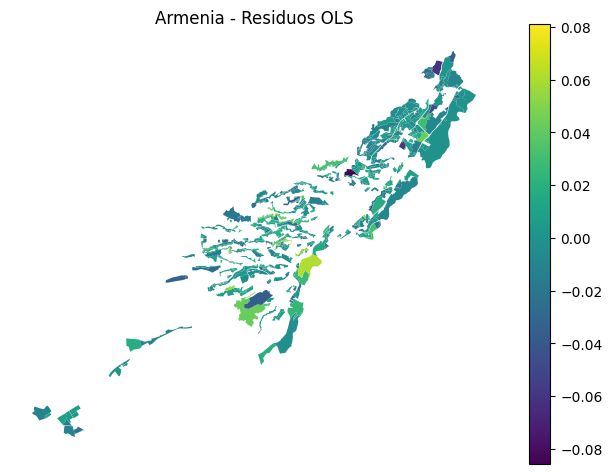


Archivos exportados para Armenia en: ETAPA 7 - SAR/outputs


In [15]:
export_sar_outputs(armenia_results, "Armenia")

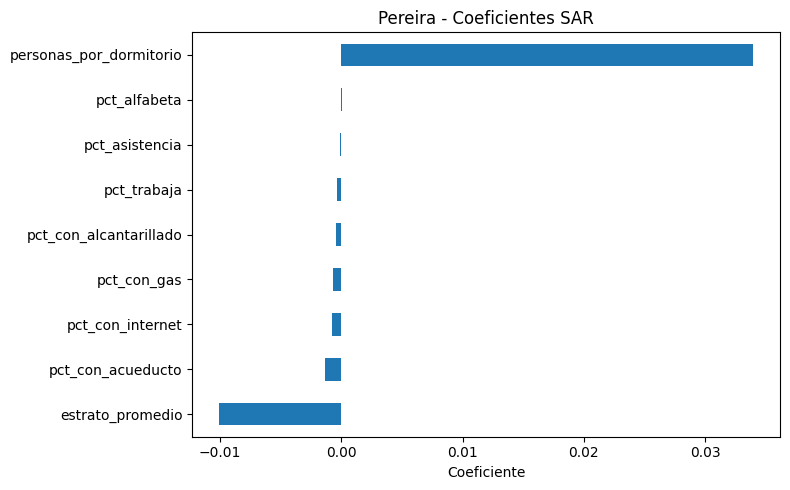

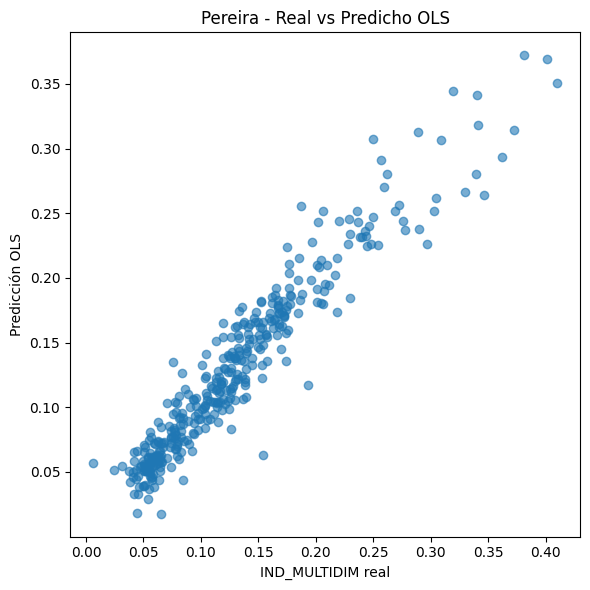

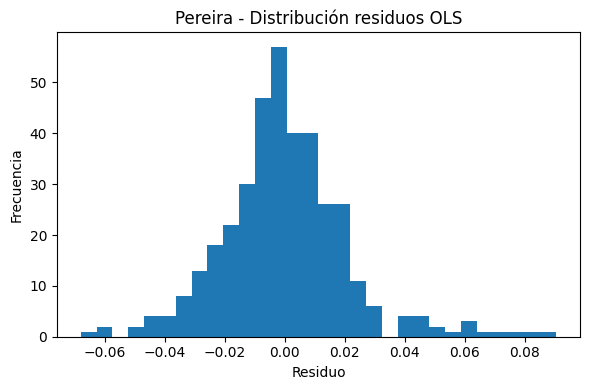

<Figure size 800x800 with 0 Axes>

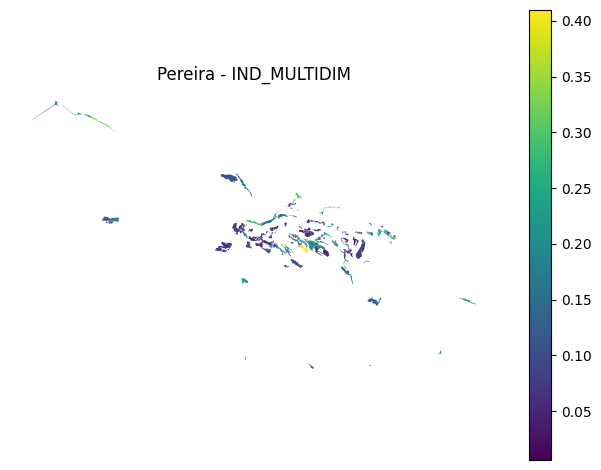

<Figure size 800x800 with 0 Axes>

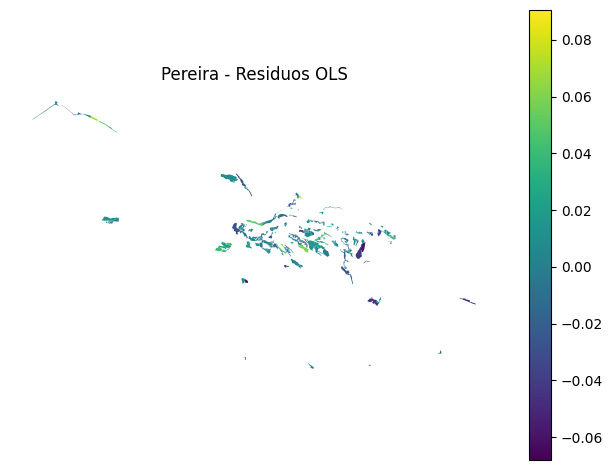


Archivos exportados para Pereira en: ETAPA 7 - SAR/outputs


In [16]:
export_sar_outputs(pereira_results, "Pereira")

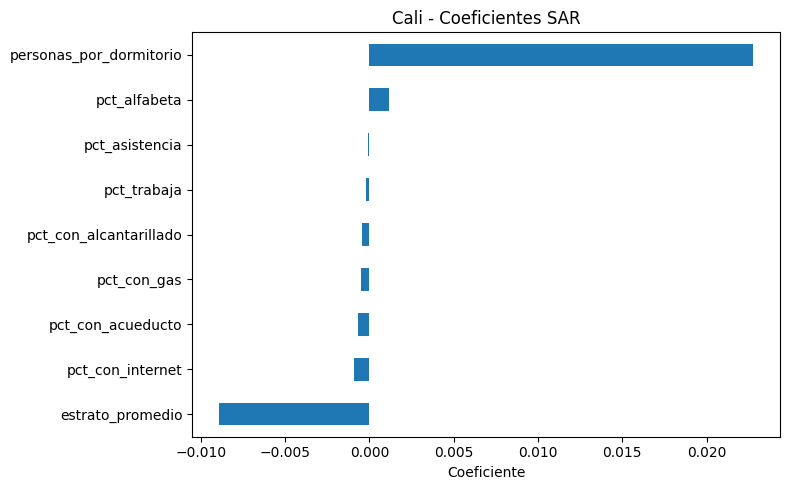

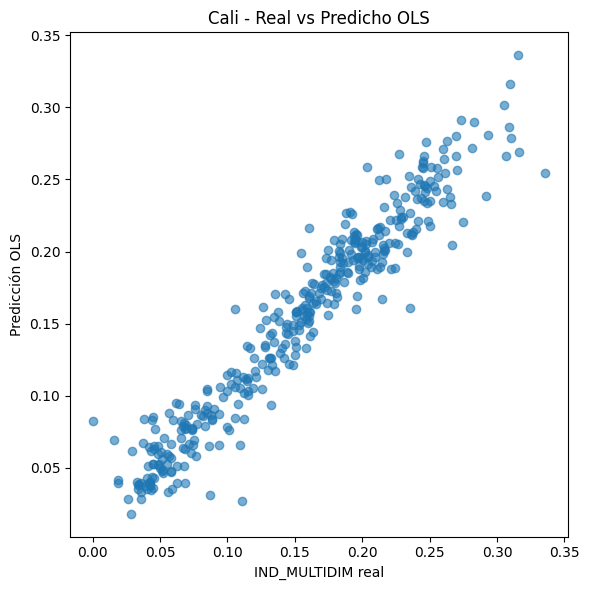

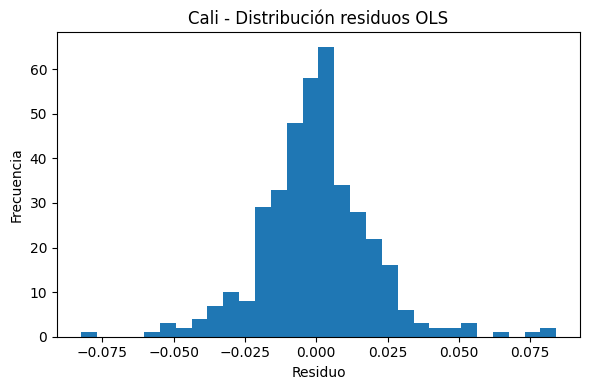

<Figure size 800x800 with 0 Axes>

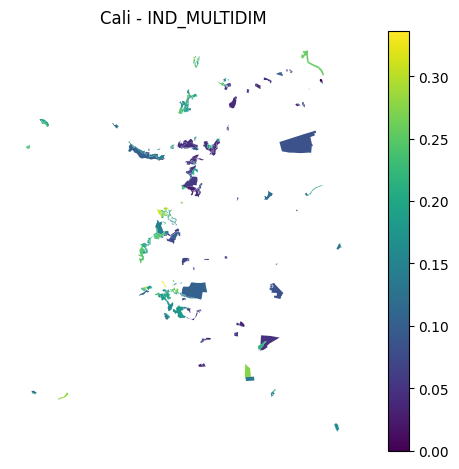

<Figure size 800x800 with 0 Axes>

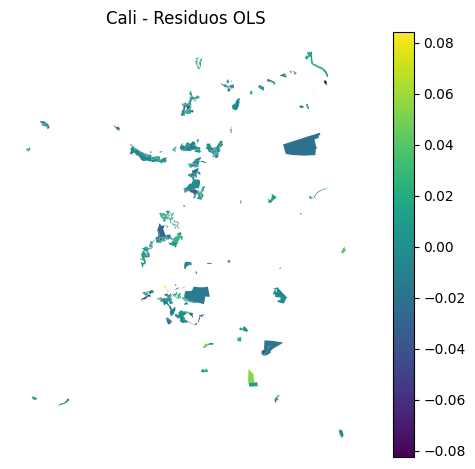


Archivos exportados para Cali en: ETAPA 7 - SAR/outputs


In [17]:
export_sar_outputs(cali_results, "Cali")

In [18]:
comparacion = pd.DataFrame({
    "Ciudad": ["Armenia", "Pereira", "Cali"],
    "N_observaciones": [
        armenia_results["gdf_model"].shape[0],
        pereira_results["gdf_model"].shape[0],
        cali_results["gdf_model"].shape[0]
    ],
    "R2_OLS": [
        armenia_results["ols"].rsquared,
        pereira_results["ols"].rsquared,
        cali_results["ols"].rsquared
    ],
    "AIC_OLS": [
        armenia_results["ols"].aic,
        pereira_results["ols"].aic,
        cali_results["ols"].aic
    ],
    "Moran_I": [
        armenia_results["moran"].I,
        pereira_results["moran"].I,
        cali_results["moran"].I
    ],
    "Moran_pvalue": [
        armenia_results["moran"].p_sim,
        pereira_results["moran"].p_sim,
        cali_results["moran"].p_sim
    ],
    "Rho_SAR": [
        float(armenia_results["sar"].rho),
        float(pereira_results["sar"].rho),
        float(cali_results["sar"].rho)
    ],
    "AIC_SAR": [
        float(armenia_results["sar"].aic),
        float(pereira_results["sar"].aic),
        float(cali_results["sar"].aic)
    ]
})

comparacion

,Ciudad,N_observaciones,R2_OLS,AIC_OLS,Moran_I,Moran_pvalue,Rho_SAR,AIC_SAR
0,Armenia,661,0.927975,-3343.688460,0.132264,0.001,0.031095,-3349.089836
1,Pereira,376,0.914608,-1814.579834,0.181348,0.002,0.033014,-1816.653113
2,Cali,389,0.929280,-1936.055041,0.142186,0.009,0.045568,-1938.795944


In [19]:
comparacion.to_csv("ETAPA 7 - SAR/outputs/comparacion_sar_ciudades.csv", index=False)